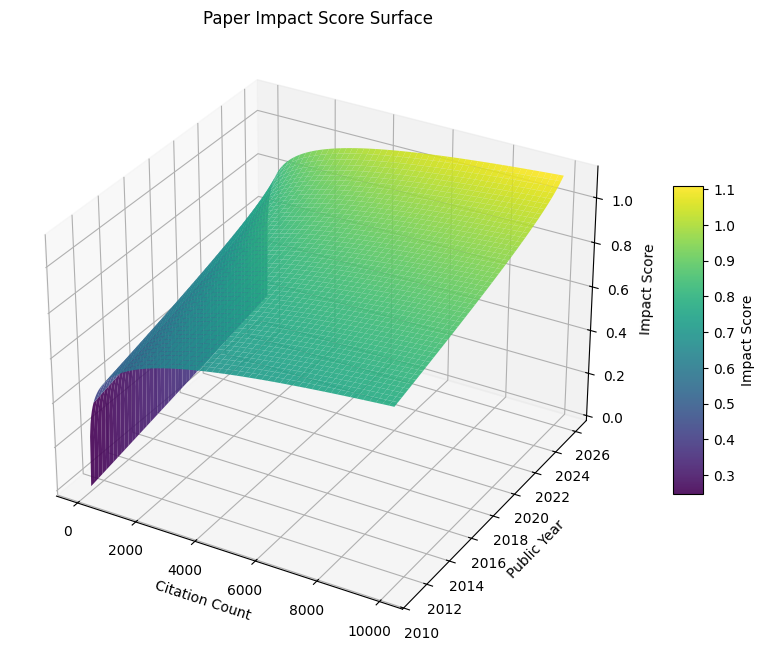

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def paper_score(c, y):
    """
    c = citation_count
    y = public_year
    """
    return (
        0.45 * np.log1p(c) / np.log(10001)
        + 0.35 * np.log1p(c / (2026 - y + 1)) / np.log(1001)
        + 0.20 * (1 - ((2026 - y) / 15))
    )


# Grid values
citation_counts = np.linspace(0, 10000, 300)
public_years = np.linspace(2011, 2026, 300)

C, Y = np.meshgrid(citation_counts, public_years)
Z = paper_score(C, Y)

# 3D surface plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(C, Y, Z, cmap="viridis", edgecolor="none", alpha=0.9)

ax.set_title("Paper Impact Score Surface")
ax.set_xlabel("Citation Count")
ax.set_ylabel("Public Year")
ax.set_zlabel("Impact Score")

fig.colorbar(surface, ax=ax, shrink=0.5, aspect=10, label="Impact Score")

plt.show()

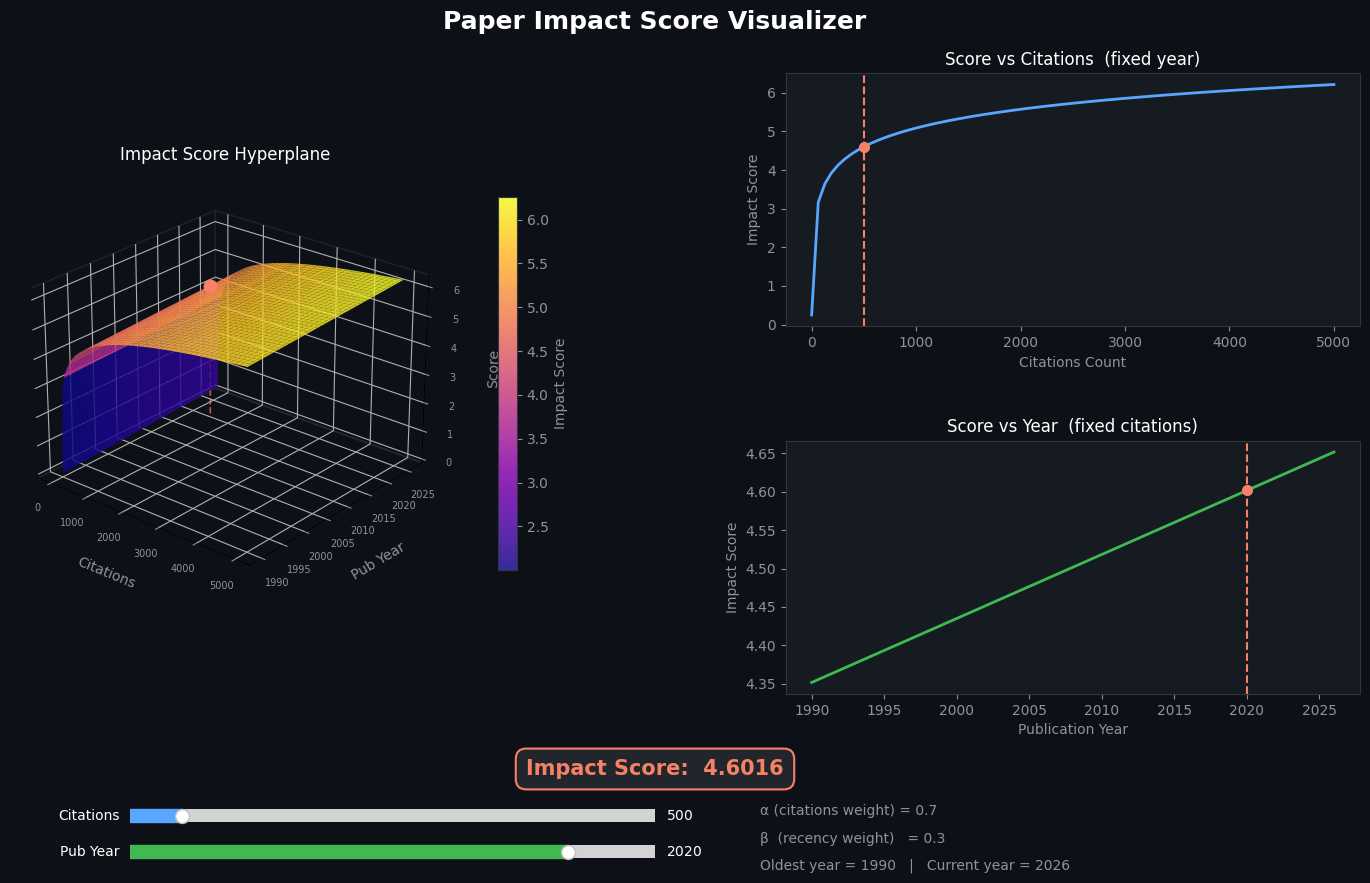

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.widgets import Slider
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ── Constants (edit these) ────────────────────────────────────────────────────
OLDEST_PAPER_YEAR = 1990
CURRENT_YEAR      = 2026
ALPHA             = 0.7   # weight for citations
BETA              = 0.3   # weight for recency
# ─────────────────────────────────────────────────────────────────────────────

def compute_impact_score(citations_count, public_year):
    year_range     = max(CURRENT_YEAR - OLDEST_PAPER_YEAR, 1)
    citation_score = math.log1p(citations_count)
    recency_score  = (public_year - OLDEST_PAPER_YEAR) / year_range
    return ALPHA * citation_score + BETA * recency_score


# ── Setup figure ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 9), facecolor="#0d1117")
fig.suptitle("Paper Impact Score Visualizer", fontsize=18, color="white",
             fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35,
                       left=0.07, right=0.97, top=0.91, bottom=0.22)

ax_surface = fig.add_subplot(gs[:, 0], projection="3d")  # full left column
ax_cit     = fig.add_subplot(gs[0, 1])                   # top right
ax_year    = fig.add_subplot(gs[1, 1])                   # bottom right

def style_ax(ax):
    ax.set_facecolor("#161b22")
    ax.tick_params(colors="#8b949e")
    ax.spines[:].set_color("#30363d")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("#8b949e")
    ax.yaxis.label.set_color("#8b949e")

for ax in [ax_cit, ax_year]:
    style_ax(ax)

# 3D axis dark styling
ax_surface.set_facecolor("#0d1117")
ax_surface.xaxis.pane.fill = False
ax_surface.yaxis.pane.fill = False
ax_surface.zaxis.pane.fill = False
ax_surface.xaxis.pane.set_edgecolor("#30363d")
ax_surface.yaxis.pane.set_edgecolor("#30363d")
ax_surface.zaxis.pane.set_edgecolor("#30363d")
ax_surface.tick_params(colors="#8b949e", labelsize=7)
ax_surface.xaxis.label.set_color("#8b949e")
ax_surface.yaxis.label.set_color("#8b949e")
ax_surface.zaxis.label.set_color("#8b949e")
ax_surface.title.set_color("white")

# ── Data ranges ───────────────────────────────────────────────────────────────
cit_range  = np.linspace(0, 5000, 80)
year_range = np.linspace(OLDEST_PAPER_YEAR, CURRENT_YEAR, 80)

INIT_CIT  = 500
INIT_YEAR = 2020

# ── 3D Surface ────────────────────────────────────────────────────────────────
C, Y = np.meshgrid(cit_range, year_range)
Z    = np.vectorize(compute_impact_score)(C, Y)

surface = ax_surface.plot_surface(C, Y, Z, cmap="plasma", alpha=0.85,
                                  linewidth=0, antialiased=True)

cbar = fig.colorbar(surface, ax=ax_surface, pad=0.1, shrink=0.6)
cbar.ax.yaxis.set_tick_params(color="#8b949e")
cbar.outline.set_edgecolor("#30363d")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#8b949e")
cbar.set_label("Impact Score", color="#8b949e")

ax_surface.set_xlabel("Citations", labelpad=8)
ax_surface.set_ylabel("Pub Year",  labelpad=8)
ax_surface.set_zlabel("Score",     labelpad=8)
ax_surface.set_title("Impact Score Hyperplane")
ax_surface.view_init(elev=25, azim=-50)

# point marker on surface
init_score = compute_impact_score(INIT_CIT, INIT_YEAR)
dot = ax_surface.plot([INIT_CIT], [INIT_YEAR], [init_score],
                      "o", color="#f78166", ms=9, zorder=5)[0]

# vertical drop line to the base
vdrop, = ax_surface.plot([INIT_CIT, INIT_CIT], [INIT_YEAR, INIT_YEAR],
                         [0, init_score], color="#f78166", lw=1.2,
                         ls="--", alpha=0.7)

# ── Citations curve ───────────────────────────────────────────────────────────
cit_scores = [compute_impact_score(c, INIT_YEAR) for c in cit_range]
[cit_line] = ax_cit.plot(cit_range, cit_scores, color="#58a6ff", lw=2)
cit_marker = ax_cit.axvline(INIT_CIT, color="#f78166", lw=1.5, ls="--")
cit_dot    = ax_cit.plot(INIT_CIT, compute_impact_score(INIT_CIT, INIT_YEAR),
                         "o", color="#f78166", ms=7, zorder=5)[0]
ax_cit.set_xlabel("Citations Count")
ax_cit.set_ylabel("Impact Score")
ax_cit.set_title("Score vs Citations  (fixed year)")

# ── Year curve ────────────────────────────────────────────────────────────────
year_scores = [compute_impact_score(INIT_CIT, y) for y in year_range]
[year_line] = ax_year.plot(year_range, year_scores, color="#3fb950", lw=2)
year_marker = ax_year.axvline(INIT_YEAR, color="#f78166", lw=1.5, ls="--")
year_dot    = ax_year.plot(INIT_YEAR, compute_impact_score(INIT_CIT, INIT_YEAR),
                           "o", color="#f78166", ms=7, zorder=5)[0]
ax_year.set_xlabel("Publication Year")
ax_year.set_ylabel("Impact Score")
ax_year.set_title("Score vs Year  (fixed citations)")

# ── Score label ───────────────────────────────────────────────────────────────
score_text = fig.text(
    0.5, 0.13,
    f"Impact Score:  {compute_impact_score(INIT_CIT, INIT_YEAR):.4f}",
    ha="center", fontsize=15, color="#f78166", fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#21262d", edgecolor="#f78166", lw=1.5)
)

# ── Sliders ───────────────────────────────────────────────────────────────────
slider_kw = dict(facecolor="#21262d")

ax_sl_cit  = fig.add_axes([0.15, 0.07, 0.35, 0.03], facecolor="#21262d")
ax_sl_year = fig.add_axes([0.15, 0.03, 0.35, 0.03], facecolor="#21262d")

sl_cit  = Slider(ax_sl_cit,  "Citations",  0, 5000,
                 valinit=INIT_CIT,  valstep=1,   color="#58a6ff")
sl_year = Slider(ax_sl_year, "Pub Year",
                 OLDEST_PAPER_YEAR, CURRENT_YEAR,
                 valinit=INIT_YEAR, valstep=1,   color="#3fb950")

for sl in [sl_cit, sl_year]:
    sl.label.set_color("white")
    sl.valtext.set_color("white")

# constant labels
fig.text(0.57, 0.085, f"α (citations weight) = {ALPHA}", color="#8b949e", fontsize=10)
fig.text(0.57, 0.055, f"β  (recency weight)   = {BETA}",  color="#8b949e", fontsize=10)
fig.text(0.57, 0.025, f"Oldest year = {OLDEST_PAPER_YEAR}   |   Current year = {CURRENT_YEAR}",
         color="#8b949e", fontsize=10)

# ── Update callback ───────────────────────────────────────────────────────────
def update(_):
    c = int(sl_cit.val)
    y = int(sl_year.val)
    score = compute_impact_score(c, y)

    # 3D point + drop line
    dot.set_data_3d([c], [y], [score])
    vdrop.set_data_3d([c, c], [y, y], [0, score])

    # citations curve
    new_cit_scores = [compute_impact_score(cx, y) for cx in cit_range]
    cit_line.set_ydata(new_cit_scores)
    ax_cit.set_ylim(min(new_cit_scores) - 0.1, max(new_cit_scores) + 0.1)
    cit_marker.set_xdata([c, c])
    cit_dot.set_data([c], [score])
    ax_cit.set_title(f"Score vs Citations  (year = {y})")

    # year curve
    new_year_scores = [compute_impact_score(c, yr) for yr in year_range]
    year_line.set_ydata(new_year_scores)
    ax_year.set_ylim(min(new_year_scores) - 0.05, max(new_year_scores) + 0.05)
    year_marker.set_xdata([y, y])
    year_dot.set_data([y], [score])
    ax_year.set_title(f"Score vs Year  (citations = {c})")

    score_text.set_text(f"Impact Score:  {score:.4f}")
    fig.canvas.draw_idle()

sl_cit.on_changed(update)
sl_year.on_changed(update)

plt.show()